### Plot initial Configuration of Particles, and their Path over time (regardless of comparing with multiple states)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def draw_circles(radius, centers, colors):
    fig, ax = plt.subplots()


    for i, center in enumerate(centers):
        circle = plt.Circle(center, radius, color=colors[i], fill=True)
        ax.add_artist(circle)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(np.min(centers[:, 0]) - 4 * radius, np.max(centers[:, 0]) + 4 * radius)
    ax.set_ylim(np.min(centers[:, 1]) - 4 * radius, np.max(centers[:, 1]) + 4 * radius)
    plt.show()

def readPositions(filename):
    data = np.loadtxt(filename)[:, 1:]
    numSteps = data.shape[0]
    numParticles = data.shape[1] // 2
    positions = data.reshape(numSteps, numParticles, 2)
    return positions

def plotTraj(inputs, labels):
    num_plots = len(inputs)
    
    fig, axs = plt.subplots(num_plots, 2, figsize=(10, 5 * num_plots))
    
    if num_plots == 1:
        axs = np.array([axs])

    for j, fname in enumerate(inputs):
        label = labels[j]
        pos = readPositions(fname)

        axs[j][0].scatter(pos[0, :, 0], pos[0, :, 1], label='Initial Positions', color='blue')
        axs[j][0].scatter(pos[-1, :, 0], pos[-1, :, 1], label='Final Positions', marker='x', color='red')
        axs[j][0].set_title('Initial and final positions', fontsize = 15)
        axs[j][0].set_ylabel(label, fontsize = 15)
        axs[j][0].legend()

        for i in range(pos.shape[1]):
            axs[j][1].plot(pos[:, i, 0], pos[:, i, 1], lw=.5)
        axs[j][1].set_title(label, fontsize = 15)
    
    plt.tight_layout()
    plt.show()

particle = np.loadtxt("/home/hadis/custom_vector/build/test/49particle_1,2N/FirsConfigPlot.dat")
particle_radius = particle[0, 2]
particle_centers = particle[:, :2]

cmap = plt.cm.get_cmap('magma', len(particle_centers))
colors = [cmap(i) for i in range(len(particle_centers))]

draw_circles(particle_radius, particle_centers, colors)
particle.shape

inputs = ["/home/hadis/custom_vector/build_angular/N_particle_PosMD.dat"]
labels = ['Path']

plotTraj(inputs, labels)

plot average nearest neighbors over tempratures *(velocityscaling, andersen, brendsen)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_neighbors(input_temp):
    file_list = [
        (f"/home/hadis/custom_vector/build/test/49_velocityscaling{input_temp}/B_NeighborsCount.dat",
         f"/home/hadis/custom_vector/build/test/49_velocityscaling{input_temp}/B_NeighborsCount2.dat"),
        
        (f"/home/hadis/custom_vector/build/test/49_andersen{input_temp}/B_NeighborsCount.dat",
         f"/home/hadis/custom_vector/build/test/49_andersen{input_temp}/B_NeighborsCount2.dat"),
        
        (f"/home/hadis/custom_vector/build/test/49_brendsen{input_temp}/B_NeighborsCount.dat",
         f"/home/hadis/custom_vector/build/test/49_brendsen{input_temp}/B_NeighborsCount2.dat")
    ]
    
    titles = ["Velocity Scaling", "Andersen", "Brendsen"]

    fig, axs = plt.subplots(len(file_list), 2, figsize=(15, 5 * len(file_list)))
    
    for k, temp_type in enumerate(["Cool down", "Heat up"]):
        for i in range(len(file_list)):
            try:
                data = np.loadtxt(file_list[i][k])
                for j in range(1, data.shape[1]):
                    axs[i, k].plot(data[:, 0], data[:, j], label=f"Neighbor {j}")
                axs[i, k].set_xlabel("Temperature")
                axs[i, k].set_ylabel("Average Neighbors")
                axs[i, k].set_title(f"{titles[i]} - {temp_type}"+ f"{input_temp}")
                axs[i, k].legend()
            except Exception as e:
                print(f"Error loading data from {file_list[i][k]}: {e}")
    
    plt.tight_layout()
    plt.show()

input_temp = "_100_50"

plot_neighbors(input_temp)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_thermo(input_temp):
    temperatures = [
        (f"/home/hadis/custom_vector/build/test/49_velocityscaling{input_temp}/N_particle_TbeforeThermo.dat",
         f"/home/hadis/custom_vector/build/test/49_velocityscaling{input_temp}/N_particle_TafterThermo.dat"),

        (f"/home/hadis/custom_vector/build/test/49_andersen{input_temp}/N_particle_TbeforeThermo.dat",
         f"/home/hadis/custom_vector/build/test/49_andersen{input_temp}/N_particle_TafterThermo.dat"),
        
        (f"/home/hadis/custom_vector/build/test/49_brendsen{input_temp}/N_particle_TbeforeThermo.dat",
         f"/home/hadis/custom_vector/build/test/49_brendsen{input_temp}/N_particle_TafterThermo.dat")
    ]
    
    titles = ["Velocity Scaling", "Andersen", "Brendsen"]
    fig, axs = plt.subplots(len(temperatures), 1, figsize=(10, 15))
    
    for i in range(len(temperatures)):
        try:
            temper_before = np.loadtxt(temperatures[i][0])
            temper_after = np.loadtxt(temperatures[i][1])
            
            axs[i].plot(temper_before, label="Before Thermostating")
            axs[i].plot(temper_after, label="After Thermostating")
            axs[i].set_title(titles[i] + f"{input_temp}")
            axs[i].legend()
        except Exception as e:
            print(f"Error loading data from {temperatures[i]}: {e}")
    
    plt.tight_layout()
    plt.show()


input_temp = "_100_50"

plot_thermo(input_temp)

Plot for one case 

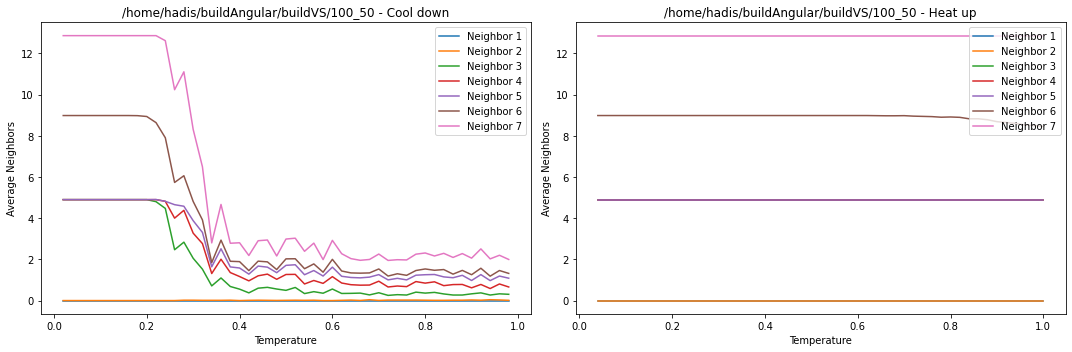

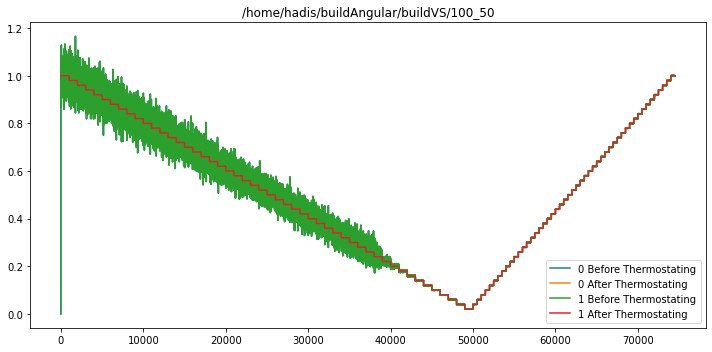

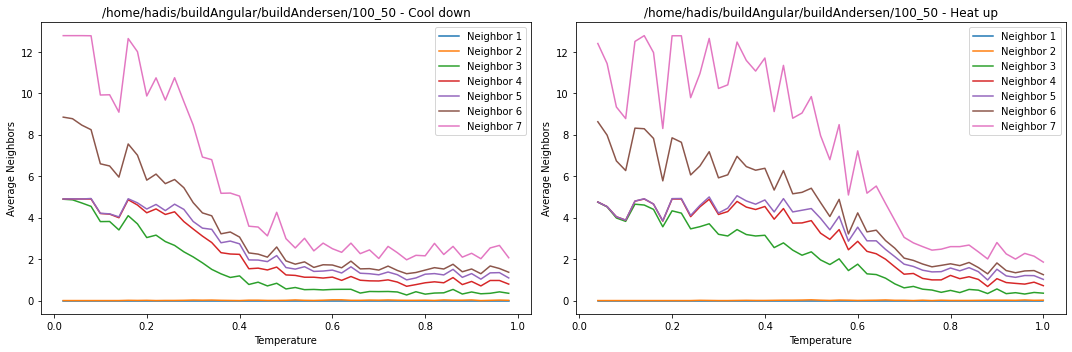

Error loading data from ('/home/hadis/buildAngular/buildAndersen/100_50/N_particle_realTbeforeThermo.dat', '/home/hadis/buildAngular/buildAndersen/100_50/N_particle_realTafterThermo.dat'): /home/hadis/buildAngular/buildAndersen/100_50/N_particle_realTbeforeThermo.dat not found.


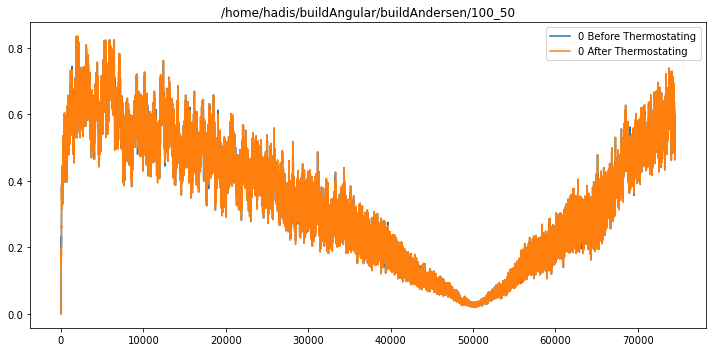

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_neighbor1(input_temp):
    file_list = [
        (f"{input_temp}/B_NeighborsCount.dat",
         f"{input_temp}/B_NeighborsCount2.dat"),
    ]    
    fig, axs = plt.subplots(len(file_list), 2, figsize=(15, 5 * len(file_list)))
    
    for k, temp_type in enumerate(["Cool down", "Heat up"]):
        try:
            data = np.loadtxt(file_list[0][k])
            for j in range(1, data.shape[1]):
                axs[k].plot(data[:, 0], data[:, j], label=f"Neighbor {j}")
            axs[k].set_xlabel("Temperature")
            axs[k].set_ylabel("Average Neighbors")
            axs[k].set_title(f"{input_temp} - {temp_type}")
            axs[k].legend()
        except Exception as e:
            print(f"Error loading data from {file_list[0][k]}: {e}")
    
    plt.tight_layout()
    plt.show()

def plot_thermo1(input_temp):
    temperatures = [
        (f"{input_temp}/N_particle_TbeforeThermo.dat",
         f"{input_temp}/N_particle_TafterThermo.dat"),
         (f"{input_temp}/N_particle_realTbeforeThermo.dat",
         f"{input_temp}/N_particle_realTafterThermo.dat")
    ]    
    fig, axs = plt.subplots(1, 1, figsize=(10, 5))
    for k in range (len(temperatures)):
        try:
            temper_before = np.loadtxt(temperatures[k][0])
            temper_after = np.loadtxt(temperatures[k][1])
            
            axs.plot(temper_before, label=f"{k} Before Thermostating")
            axs.plot(temper_after, label=f"{k} After Thermostating")
            axs.set_title(f"{input_temp}")
            axs.legend()
        except Exception as e:
            print(f"Error loading data from {temperatures[k]}: {e}")
        
    plt.tight_layout()
    plt.show()


input_temp1 = "/home/hadis/buildAngular/buildVS/100_50"
input_temp2 = "/home/hadis/buildAngular/buildAndersen/100_50"

plot_neighbor1(input_temp1)
plot_thermo1(input_temp1)
plot_neighbor1(input_temp2)
plot_thermo1(input_temp2)

plot time of running for different cutoff radiouses

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cutoff_list = np.loadtxt("/home/hadis/custom_vector/build/test/B_cutoffList.dat")
runnig_time = np.loadtxt("/home/hadis/custom_vector/build/test/B_runTimeList.dat")

fig, ax = plt.subplots()
ax.plot(cutoff_list, runnig_time)

plt.show()

In [33]:
run = "/home/hadis/buildAngular/buildAndersen/100_50"

import os, sys, re
RE_stateFile = re.compile("N_Config_([0-9.]+).dat")

In [34]:
temps = []
for f in os.listdir(run):
    match = RE_stateFile.match(f)
    if match is not None:
        T = float(match[1])
        temps.append((T, np.loadtxt(os.path.join(run, f))))

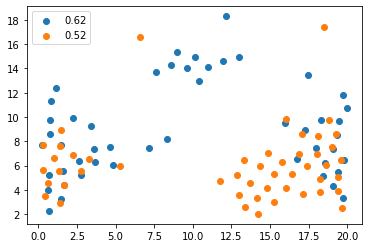

In [36]:


for T, conf in temps[0:2]:
    plt.scatter(conf[:, 0], conf[:, 1], label=str(T))
plt.legend()

In [23]:
temps[0][1].shape

(49, 4)

In [27]:
sort?

Object `sort` not found.
